# SIGCSE Problem Framing Analysis

This notebook reproduces the descriptive analysis for the SIGCSE poster extended abstract on unaided data science problem-framing drafts.

It performs five checks:

1. Load the raw submission export.
2. Filter the conservative unaided subset.
3. Load the binary component coding.
4. Reproduce draft-level and participant-level component counts.
5. Recompute inter-rater agreement from the coding workbook and regenerate the component-presence figure.


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..') if Path.cwd().name == 'notebooks' else Path('.')
DATA_DIR = ROOT / 'data'
RESULTS_DIR = ROOT / 'results'
FIG_DIR = ROOT / 'figures'

RAW_CSV = DATA_DIR / 'submissions_2026-06-18.csv'
CODING_XLSX = DATA_DIR / 'problem_framing_coding_sheet.xlsx'
RESOLVED_CODES = DATA_DIR / 'resolved_component_codes.csv'

components = [
    'Data/features',
    'Aligned problem',
    'Analytic objective',
    'Method/model',
    'Explicit constraints',
    'Stakeholder/action',
    'Success criteria',
    'Ethics/privacy/fairness',
]

scenario_components = ['Data/features']
prompt_named_components = ['Aligned problem', 'Analytic objective', 'Method/model', 'Explicit constraints', 'Success criteria']
extended_components = ['Stakeholder/action', 'Ethics/privacy/fairness']


## 1. Load the raw submission export and filter the unaided subset

The poster uses a conservative activity-based filter. A draft is retained only when no scaffold suggestion was recorded as shown and none was recorded as accepted.


In [2]:
raw = pd.read_csv(RAW_CSV)
unaided = raw[
    (raw['ai_suggestions_shown'].fillna(0).astype(int) == 0) &
    (raw['ai_suggestions_accepted'].fillna(0).astype(int) == 0)
].copy()

summary = {
    'raw_rows': len(raw),
    'unaided_rows': len(unaided),
    'raw_sessions': raw['session_id'].nunique(),
    'unaided_sessions': unaided['session_id'].nunique(),
    'intermediate_drafts': int((unaided['expertise_level'] == 'intermediate').sum()),
    'advanced_drafts': int((unaided['expertise_level'] == 'advanced').sum()),
    'word_min': int(unaided['word_count'].min()),
    'word_mean': round(float(unaided['word_count'].mean()), 1),
    'word_median': float(unaided['word_count'].median()),
    'word_max': int(unaided['word_count'].max()),
    'time_min_seconds': int(unaided['time_spent_seconds'].min()),
    'time_median_seconds': float(unaided['time_spent_seconds'].median()),
    'time_max_seconds': int(unaided['time_spent_seconds'].max()),
    'revision_min': int(unaided['revision_count'].min()),
    'revision_max': int(unaided['revision_count'].max()),
}
summary


{'raw_rows': 21,
 'unaided_rows': 15,
 'raw_sessions': 10,
 'unaided_sessions': 10,
 'intermediate_drafts': 8,
 'advanced_drafts': 7,
 'word_min': 20,
 'word_mean': 81.3,
 'word_median': 58.0,
 'word_max': 225,
 'time_min_seconds': 7,
 'time_median_seconds': 200.0,
 'time_max_seconds': 1064,
 'revision_min': 0,
 'revision_max': 83}

In [3]:
# Export the filtered subset for transparency.
RESULTS_DIR.mkdir(exist_ok=True)
unaided.to_csv(DATA_DIR / 'unaided_submissions_filtered.csv', index=False)
unaided[['session_id', 'expertise_level', 'word_count', 'revision_count', 'time_spent_seconds', 'content']].head()


,session_id,expertise_level,word_count,revision_count,time_spent_seconds,content
0,6e9b9926-e8db-4506-b3d3-94da80bf5a6b,advanced,44,0,7,The online learning platform wants to identify...
1,6e9b9926-e8db-4506-b3d3-94da80bf5a6b,advanced,44,1,162,The online learning platform wants to identify...
3,65343626-4b30-456c-a52e-a4b00e481357,advanced,63,25,220,In the domain of online learning it's been wit...
4,65343626-4b30-456c-a52e-a4b00e481357,advanced,27,16,253,In the domain of online learning it's been wit...
6,42e35cf6-4472-471f-90c6-4259b0224e6a,advanced,132,83,996,Problem statement: Why many students drop out ...


## 2. Load resolved component codes

The resolved code file contains one row per unaided draft and eight binary component codes.


In [4]:
codes = pd.read_csv(RESOLVED_CODES)
for c in components:
    codes[c] = codes[c].astype(int)

codes['draft_num'] = codes['Draft'].str.extract(r'(\d+)').astype(int)
print(codes.shape)
codes[['Draft','User','Expertise','Words'] + components].head()


(15, 16)


,Draft,User,Expertise,Words,Data/features,Aligned problem,Analytic objective,Method/model,Explicit constraints,Stakeholder/action,Success criteria,Ethics/privacy/fairness
0,D01,User 3,intermediate,22,1,0,0,0,0,0,0,0
1,D02,User 3,intermediate,22,1,0,0,0,0,0,0,0
2,D03,User 4,intermediate,20,1,0,0,0,0,0,0,0
3,D04,User 7,advanced,21,0,1,1,1,0,0,0,0
4,D05,User 8,advanced,58,1,1,1,0,1,0,1,0


## 3. Reproduce draft-level and participant-level counts

Participant-level counts use the longest unaided draft for each user. Ties are broken by the later draft identifier.


In [5]:
participant_codes = (
    codes.sort_values(['User', 'Words', 'draft_num'], ascending=[True, False, False])
         .drop_duplicates('User', keep='first')
         .copy()
)

rows = []
for c in components:
    draft_count = int(codes[c].sum())
    participant_count = int(participant_codes[c].sum())
    rows.append({
        'component': c,
        'draft_count': draft_count,
        'draft_n': len(codes),
        'draft_pct': 100 * draft_count / len(codes),
        'participant_count': participant_count,
        'participant_n': len(participant_codes),
        'participant_pct': 100 * participant_count / len(participant_codes),
    })

component_summary = pd.DataFrame(rows)
component_summary.to_csv(RESULTS_DIR / 'component_presence_summary.csv', index=False)
component_summary


,component,draft_count,draft_n,draft_pct,participant_count,participant_n,participant_pct
0,Data/features,13,15,86.666667,9,10,90.0
1,Aligned problem,12,15,80.000000,8,10,80.0
2,Analytic objective,11,15,73.333333,8,10,80.0
3,Method/model,10,15,66.666667,7,10,70.0
4,Explicit constraints,6,15,40.000000,4,10,40.0
5,Stakeholder/action,6,15,40.000000,4,10,40.0
6,Success criteria,5,15,33.333333,3,10,30.0
7,Ethics/privacy/fairness,3,15,20.000000,2,10,20.0


In [6]:
participant_codes[['Draft','User','Expertise','Words'] + components]


,Draft,User,Expertise,Words,Data/features,Aligned problem,Analytic objective,Method/model,Explicit constraints,Stakeholder/action,Success criteria,Ethics/privacy/fairness
7,D08,User 10,intermediate,122,1,1,1,1,1,1,1,0
9,D10,User 11,intermediate,225,1,1,1,1,1,1,1,1
10,D11,User 12,advanced,132,1,1,1,1,1,0,0,1
12,D13,User 13,advanced,63,1,1,1,1,0,1,0,0
14,D15,User 15,advanced,44,1,1,1,1,0,0,0,0
1,D02,User 3,intermediate,22,1,0,0,0,0,0,0,0
2,D03,User 4,intermediate,20,1,0,0,0,0,0,0,0
3,D04,User 7,advanced,21,0,1,1,1,0,0,0,0
4,D05,User 8,advanced,58,1,1,1,0,1,0,1,0
5,D06,User 9,intermediate,74,1,1,1,1,0,1,0,0


## 4. Recompute inter-rater agreement

This step reads the `Rater 1` and `Rater 2` tabs in the coding workbook, aligns the 15 coded drafts by draft ID, and computes percent agreement and Cohen's kappa manually.


In [7]:
def load_rater(sheet_name):
    df = pd.read_excel(CODING_XLSX, sheet_name=sheet_name)
    df = df[df['Draft'].astype(str).str.match(r'^D\d{2}$', na=False)].copy()
    df = df.set_index('Draft')
    return df

r1 = load_rater('Rater 1')
r2 = load_rater('Rater 2')
common = sorted(set(r1.index) & set(r2.index), key=lambda x: int(x[1:]))
r1 = r1.loc[common]
r2 = r2.loc[common]

y1 = r1[components].astype(int).to_numpy().ravel()
y2 = r2[components].astype(int).to_numpy().ravel()

po = float((y1 == y2).mean())
p1 = y1.mean()
p2 = y2.mean()
pe = p1 * p2 + (1 - p1) * (1 - p2)
kappa = (po - pe) / (1 - pe)

agreement = pd.DataFrame([{
    'decisions': len(y1),
    'agreement_pct': 100 * po,
    'cohens_kappa': kappa,
    'both_1': int(((y1 == 1) & (y2 == 1)).sum()),
    'r1_1_r2_0': int(((y1 == 1) & (y2 == 0)).sum()),
    'r1_0_r2_1': int(((y1 == 0) & (y2 == 1)).sum()),
    'both_0': int(((y1 == 0) & (y2 == 0)).sum()),
}])
agreement.to_csv(RESULTS_DIR / 'inter_rater_agreement.csv', index=False)
agreement


,decisions,agreement_pct,cohens_kappa,both_1,r1_1_r2_0,r1_0_r2_1,both_0
0,120,95.0,0.89899,63,3,3,51


In [8]:
# Show the exact cells where raters disagreed.
disagreements = []
for draft in common:
    for c in components:
        if int(r1.loc[draft, c]) != int(r2.loc[draft, c]):
            disagreements.append({
                'Draft': draft,
                'User': r2.loc[draft, 'User'],
                'component': c,
                'Rater 1': int(r1.loc[draft, c]),
                'Rater 2': int(r2.loc[draft, c]),
                'Draft text': r2.loc[draft, 'Draft text'],
            })

disagreement_df = pd.DataFrame(disagreements)
disagreement_df.to_csv(RESULTS_DIR / 'coding_disagreements.csv', index=False)
disagreement_df


,Draft,User,component,Rater 1,Rater 2,Draft text
0,D01,User 3,Analytic objective,1,0,What type of content is being maximum consumed...
1,D02,User 3,Analytic objective,1,0,What type of content is being maximum consumed...
2,D03,User 4,Analytic objective,1,0,What content is consumed on the maximum level ...
3,D05,User 8,Explicit constraints,0,1,Problem statement is to find why students fail...
4,D11,User 12,Data/features,0,1,Problem statement: Why many students drop out ...
5,D13,User 13,Method/model,0,1,In the domain of online learning it's been wit...


## 5. Regenerate the component-presence figure

The figure separates the single scenario-derived data component, the five prompt-named facets, and the two extended responsible-framing indicators.


PosixPath('../figures/component_presence_reproduced.png')

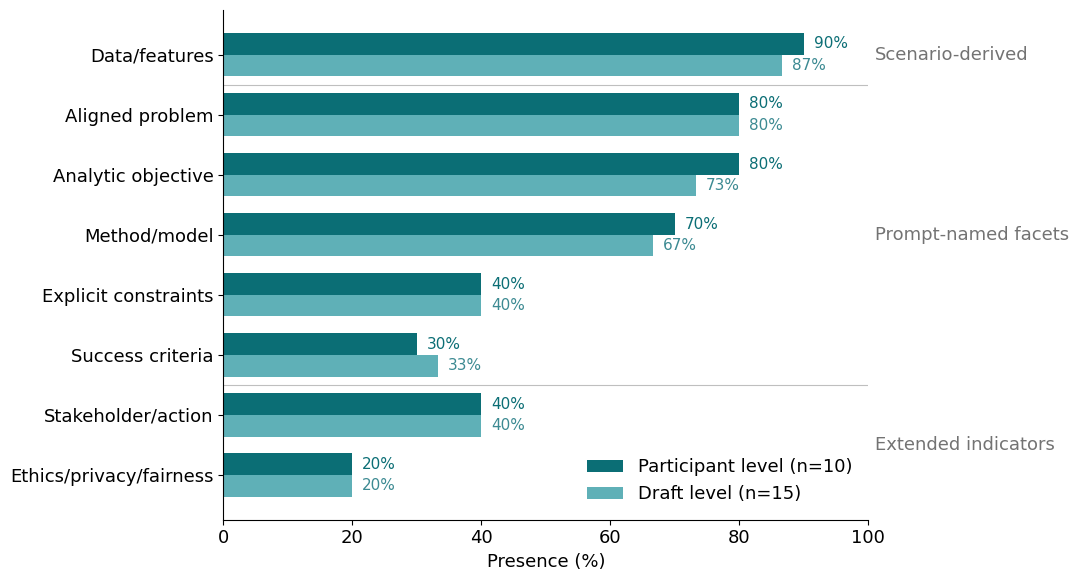

In [9]:
# Plot order and labels used in the manuscript figure.
plot_order = [
    'Data/features','Aligned problem','Analytic objective','Method/model',
    'Explicit constraints','Success criteria','Stakeholder/action','Ethics/privacy/fairness',
]
labels = list(plot_order)

plot_df = component_summary.set_index('component').loc[plot_order].reset_index()
y = np.arange(len(plot_df))
height = 0.36

PC = '#0B6E75'   # participant level (primary)
DC = '#5FB0B7'   # draft level (transparency check)
LBL = '#3C8A92'  # readable label for the lighter bars

plt.rcParams.update({'font.size': 13})
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(y - height/2, plot_df['participant_pct'], height, color=PC, label='Participant level (n=10)')
ax.barh(y + height/2, plot_df['draft_pct'], height, color=DC, label='Draft level (n=15)')
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel('Presence (%)')
ax.legend(frameon=False, loc='lower right')
ax.spines[['top','right']].set_visible(False)

ax.axhline(0.5, color='0.75', linewidth=0.8)
ax.axhline(5.5, color='0.75', linewidth=0.8)
ax.text(101, 0, 'Scenario-derived', va='center', color='0.45')
ax.text(101, 3, 'Prompt-named facets', va='center', color='0.45')
ax.text(101, 6.5, 'Extended indicators', va='center', color='0.45')

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(row['participant_pct'] + 1.5, i - height/2, f"{row['participant_pct']:.0f}%", va='center', color=PC, fontsize=11)
    ax.text(row['draft_pct'] + 1.5, i + height/2, f"{row['draft_pct']:.0f}%", va='center', color=LBL, fontsize=11)

fig.tight_layout()
FIG_DIR.mkdir(exist_ok=True)
out = FIG_DIR / 'component_presence_reproduced.png'
fig.savefig(out, dpi=300, bbox_inches='tight')
out


## 6. Manuscript-ready values

These are the manuscript values reproduced by the notebook.


In [10]:
print(f"Unaided subset: {len(unaided)} drafts from {unaided['session_id'].nunique()} sessions")
print(f"Draft expertise split: {(unaided['expertise_level']=='intermediate').sum()} intermediate / {(unaided['expertise_level']=='advanced').sum()} advanced")
print(f"Participant expertise split from coded drafts: {(participant_codes['Expertise']=='intermediate').sum()} intermediate / {(participant_codes['Expertise']=='advanced').sum()} advanced")
print(f"Word count range: {unaided['word_count'].min()}–{unaided['word_count'].max()}, mean {unaided['word_count'].mean():.1f}, median {unaided['word_count'].median():.0f}")
print(f"Time range: {unaided['time_spent_seconds'].min()}–{unaided['time_spent_seconds'].max()} seconds, median {unaided['time_spent_seconds'].median():.0f}")
print(f"Revision range: {unaided['revision_count'].min()}–{unaided['revision_count'].max()}")
print(f"Agreement: {agreement.loc[0,'agreement_pct']:.1f}% across {int(agreement.loc[0,'decisions'])} decisions; Cohen's kappa = {agreement.loc[0,'cohens_kappa']:.2f}")
component_summary[['component','participant_count','participant_n','participant_pct','draft_count','draft_n','draft_pct']]


Unaided subset: 15 drafts from 10 sessions
Draft expertise split: 8 intermediate / 7 advanced
Participant expertise split from coded drafts: 5 intermediate / 5 advanced
Word count range: 20–225, mean 81.3, median 58
Time range: 7–1064 seconds, median 200
Revision range: 0–83
Agreement: 95.0% across 120 decisions; Cohen's kappa = 0.90


,component,participant_count,participant_n,participant_pct,draft_count,draft_n,draft_pct
0,Data/features,9,10,90.0,13,15,86.666667
1,Aligned problem,8,10,80.0,12,15,80.000000
2,Analytic objective,8,10,80.0,11,15,73.333333
3,Method/model,7,10,70.0,10,15,66.666667
4,Explicit constraints,4,10,40.0,6,15,40.000000
5,Stakeholder/action,4,10,40.0,6,15,40.000000
6,Success criteria,3,10,30.0,5,15,33.333333
7,Ethics/privacy/fairness,2,10,20.0,3,15,20.000000
